# Fashion-MNIST Classification with CNN
**A step-by-step pipeline from data loading to saving the model for Streamlit.**


## Step 1: Import Libraries and Set Random Seed
Import required libraries (TensorFlow, NumPy, Matplotlib, etc.) and set random seeds.


In [19]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")


TensorFlow Version: 2.21.0


## Step 2: Load Dataset and Inspect Shapes
Load Fashion-MNIST data and check train/test shapes and labels.


In [20]:
# Load Fashion-MNIST dataset from Keras
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Define class names
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Train images shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Test images shape:  {X_test.shape}, Labels shape:  {y_test.shape}")
print(f"Pixel value range:  min={X_train.min()}, max={X_train.max()}")
print(f"Data type:          {X_train.dtype}")


Train images shape: (60000, 28, 28), Labels shape: (60000,)
Test images shape:  (10000, 28, 28), Labels shape:  (10000,)
Pixel value range:  min=0, max=255
Data type:          uint8


## Step 3: Data Visualization (EDA)
Plot sample images with their class names and inspect class balance.


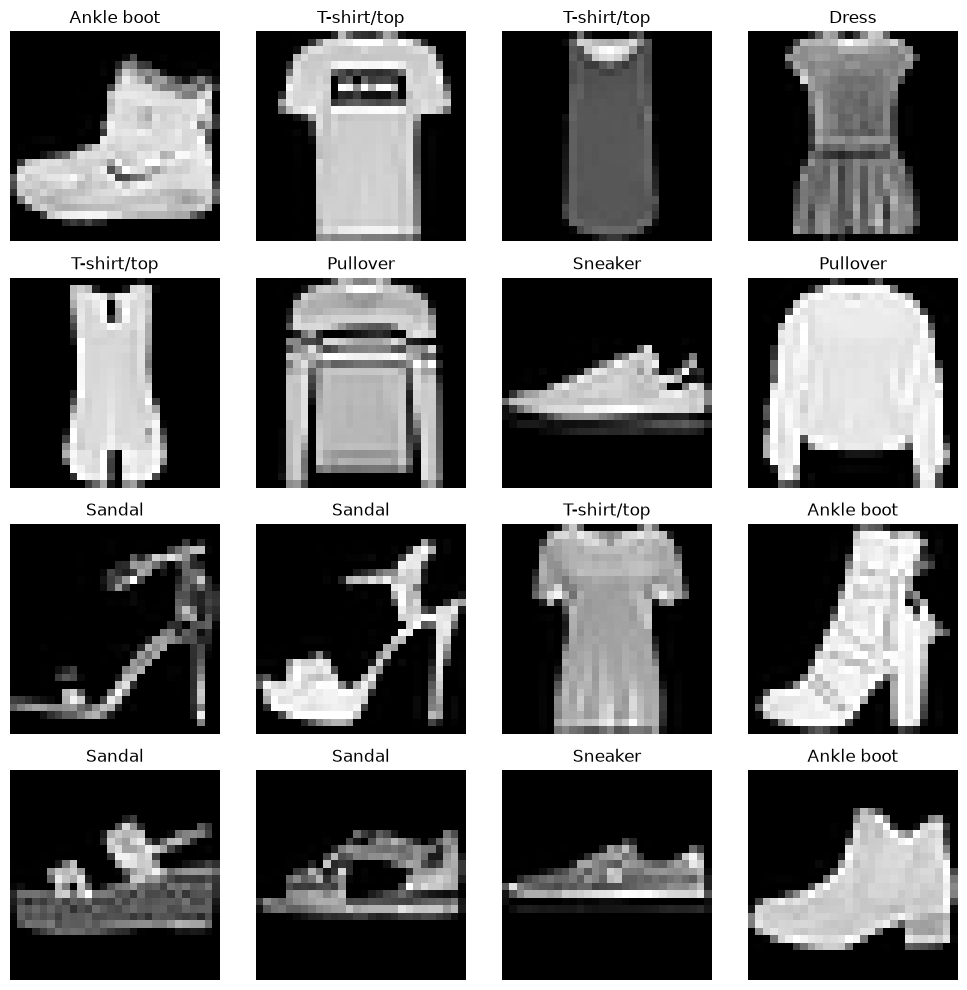

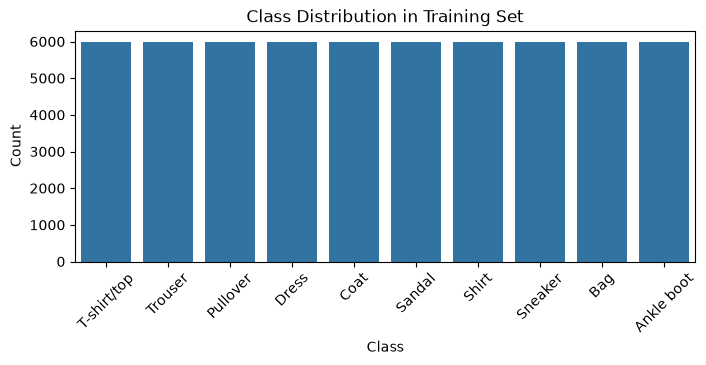

In [21]:
# Plot sample images with class names
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Check class distribution
plt.figure(figsize=(8, 3))
sns.countplot(x=y_train)
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


### Explanation:


## Step 4: Data Preprocessing
Normalize pixel values (divide by 255.0) and reshape images to (28, 28, 1).


In [22]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# 1. Normalize pixel values to [0.0, 1.0]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# 2. Reshape to add channel dimension (28, 28, 1) for Conv2D
X_train_norm = np.expand_dims(X_train_norm, axis=-1)
X_test_norm = np.expand_dims(X_test_norm, axis=-1)

# 3. Create validation split (50,000 train, 10,000 val)
val_split = 10000
X_val = X_train_norm[-val_split:]
y_val = y_train[-val_split:]
X_train_final = X_train_norm[:-val_split]
y_train_final = y_train[:-val_split]

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_val shape:         {X_val.shape}")
print(f"X_test_norm shape:   {X_test_norm.shape}")



X_train_final shape: (50000, 28, 28, 1)
X_val shape:         (10000, 28, 28, 1)
X_test_norm shape:   (10000, 28, 28, 1)


## Step 5: Build CNN Model Architecture
Design the CNN layers (Conv2D, MaxPooling2D, Dropout, Dense, Softmax) and print model summary.


In [23]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    # Conv Block 1
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    # Conv Block 2
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

## Step 6: Compile the Model
Configure optimizer (e.g., Adam), loss function, and metrics.


In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")


Model compiled successfully.


## Step 7: Train the Model & Callbacks
Train the model using model.fit() with callbacks like EarlyStopping.


In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train_final, y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.7689 - loss: 0.6477 - val_accuracy: 0.8619 - val_loss: 0.3772 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8384 - loss: 0.4439 - val_accuracy: 0.8893 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8610 - loss: 0.3830 - val_accuracy: 0.8908 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8686 - loss: 0.3586 - val_accuracy: 0.8900 - val_loss: 0.2969 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8791 - loss: 0.3326 - val_accuracy: 0.9035 - val_loss: 0.2597 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8830 - loss: 0.3180 - val_accuracy: 0.9101 - val_loss: 0.2555 - learning_rate: 0.0010
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8881 - l

## Step 8: Model Evaluation & Performance Curves
Plot training/validation loss & accuracy curves, and compute the confusion matrix.


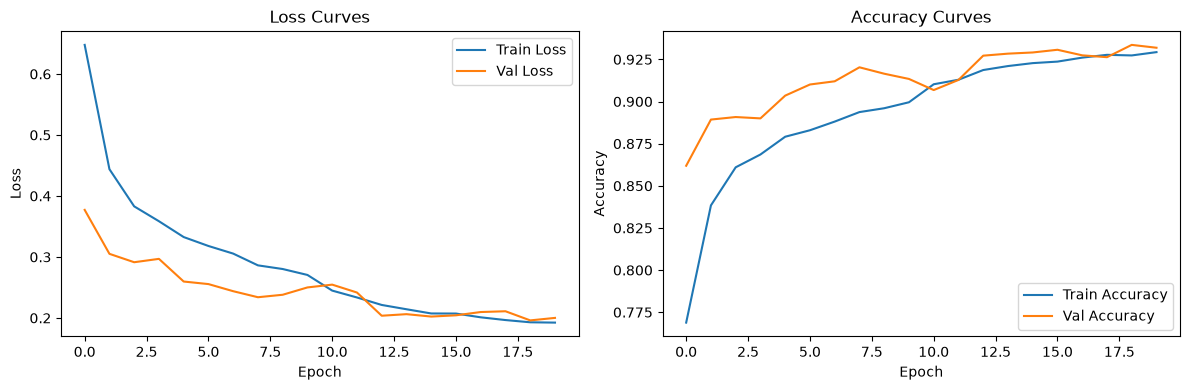

Test Loss:     0.2255
Test Accuracy: 92.46%

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.89      0.88      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.89      0.90      0.89      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.88      0.89      0.88      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.80      0.74      0.77      1000
     Sneaker       0.95      0.99      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



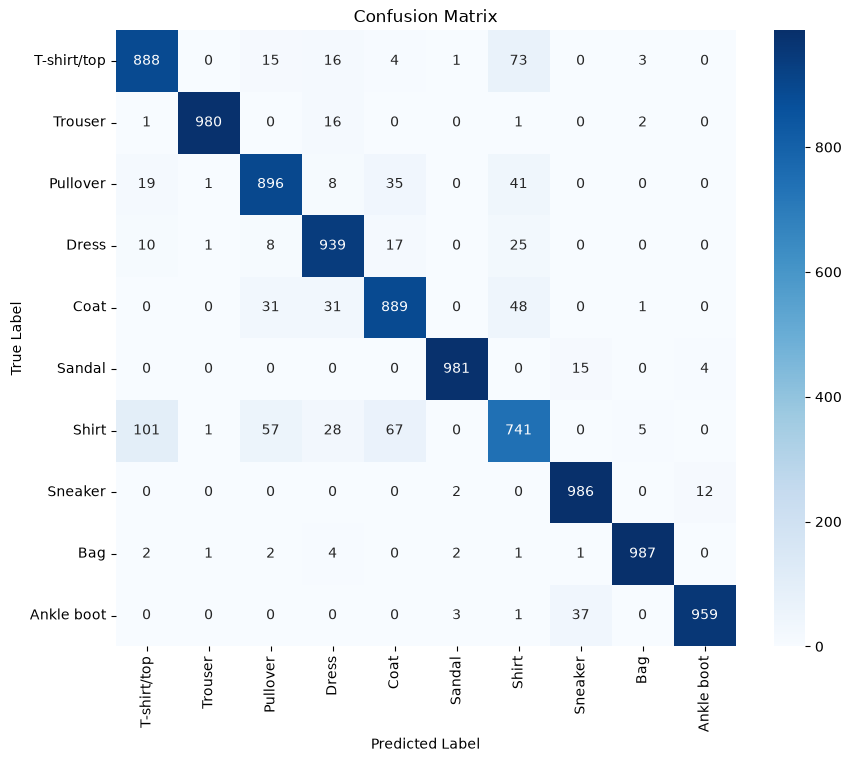

In [26]:
# 1. Plot Loss & Accuracy Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# 3. Confusion Matrix & Report
y_pred_probs = model.predict(X_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Step 9: Test Predictions on Sample Images
Predict classes on test samples and display predictions with confidence scores.


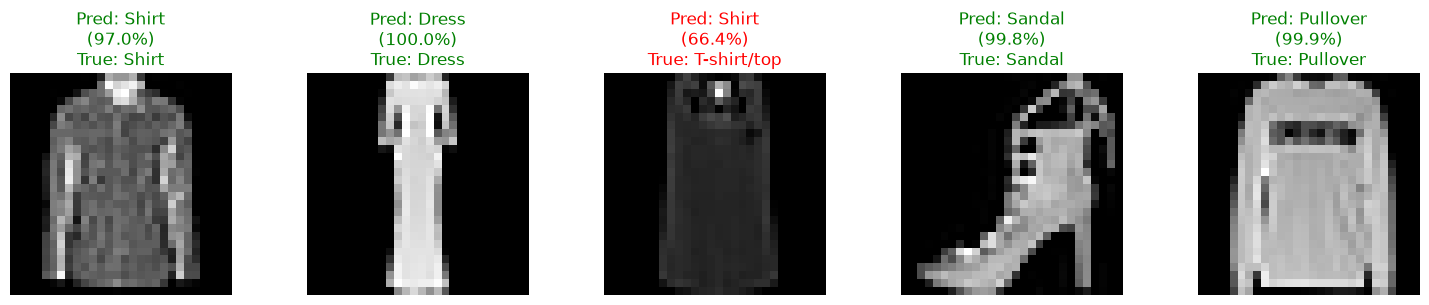

In [27]:
# Select 5 random test samples
sample_indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(sample_indices):
    sample_img = X_test_norm[idx]
    true_label = CLASS_NAMES[y_test[idx]]
    
    # Predict
    pred_probs = model.predict(np.expand_dims(sample_img, axis=0), verbose=0)[0]
    pred_label = CLASS_NAMES[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_img.squeeze(), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\n({confidence:.1f}%)\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Step 10: Save Model and Class Names for Streamlit
Save the trained model (.keras or .h5) and class names JSON for Streamlit deployment.


In [28]:
# 1. Save model in modern Keras format
MODEL_PATH = 'fashion_mnist_model.keras'
model.save(MODEL_PATH)
print(f"Model saved successfully to: {MODEL_PATH}")

# 2. Save class names to JSON for Streamlit
JSON_PATH = 'class_names.json'
with open(JSON_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=4)
print(f"Class names saved to: {JSON_PATH}")

reloaded_model = keras.models.load_model(MODEL_PATH)
sample_input = X_test_norm[:1]
orig_pred = model.predict(sample_input, verbose=0)
reloaded_pred = reloaded_model.predict(sample_input, verbose=0)

np.testing.assert_allclose(orig_pred, reloaded_pred, rtol=1e-5)
print("Sanity check passed: Reloaded model matches original predictions!")


Model saved successfully to: fashion_mnist_model.keras
Class names saved to: class_names.json
Sanity check passed: Reloaded model matches original predictions!
